In [1]:
from capture_utils_v2 import CaptureSystem

# Initialize the capture system
system = CaptureSystem()


Pixel format set to RGB8
IC4 Grabber and Sink initialized.


showing
[[23]
 [40]]
[[23]
 [40]]
[[23]
 [40]]
[[23]
 [40]]


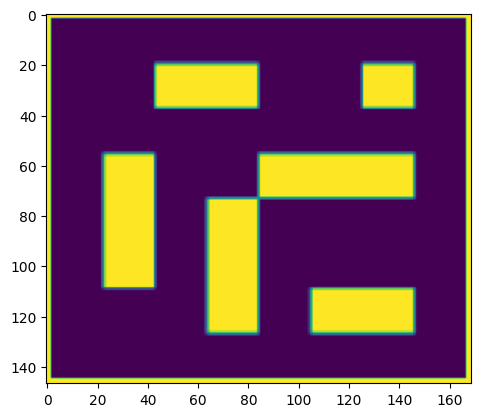

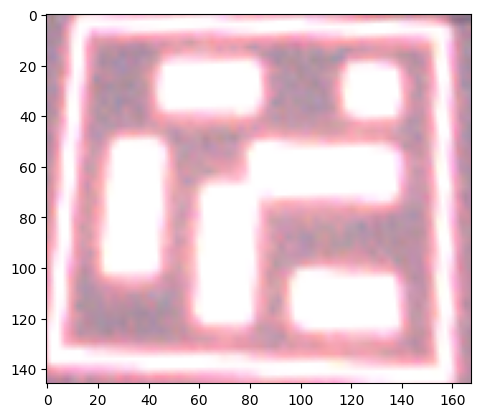

In [2]:
system.display_drawer()
system.run_aruco_detector()


In [65]:
import matplotlib.pyplot as plt
import cv2

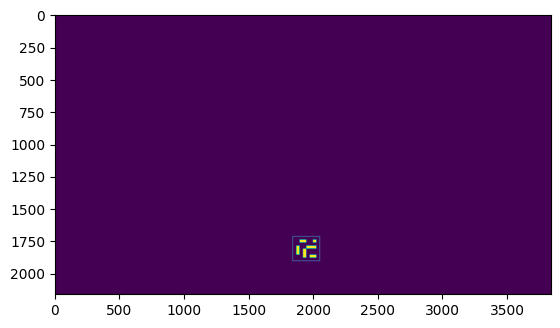

In [66]:
plt.imshow(system.img)


In [67]:
cv2.namedWindow("Rectangle Window", cv2.WND_PROP_FULLSCREEN)
cv2.setWindowProperty("Rectangle Window", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
cv2.imshow("Rectangle Window", system.img)
wk = cv2.waitKey(10)
if wk == 27 or wk == 99:  # ESC key to exit or 'c' to capture
    cv2.destroyAllWindows()


In [88]:
system.img_non_zero_section_corners

array([[  2.,   2.],
       [208.,   2.],
       [208., 188.],
       [  2., 188.]], dtype=float32)

In [89]:
system.orig_proj_corners

array([[1836, 1714],
       [2046, 1714],
       [2046, 1904],
       [1836, 1904]])

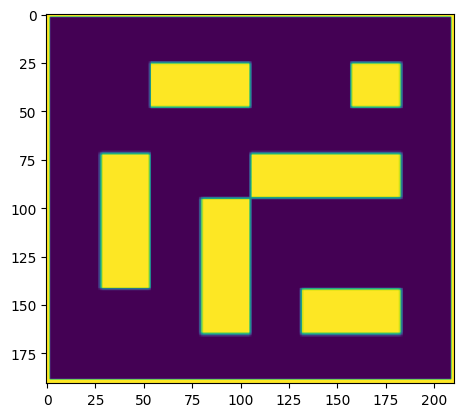

In [68]:
plt.imshow(system.to_place)

# Homography Tracking for Printed and Projected ArUco Markers

This section computes homographies for both the printed ArUco (ID 23) and projected ArUco (ID 40), 
then learns a transformation to maintain the relative position when the printed marker moves.

Detected marker IDs: [23 40]


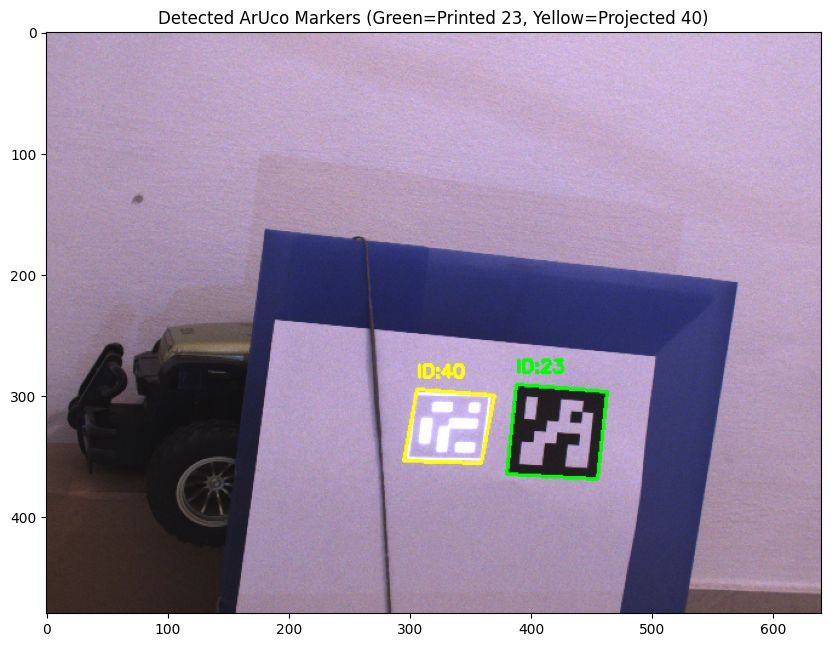

In [90]:
# ArUco marker IDs
printed_aruco_id = 23
projected_aruco_id = 40

# Setup ArUco detector
detectorParams = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(system.aruco_dict, detectorParams)

# Capture frame with both markers visible
ret, frame = system.cap.read()
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
corners, ids, _ = detector.detectMarkers(gray)

print(f"Detected marker IDs: {ids.flatten() if ids is not None else 'None'}")

# Visualize detected markers
frame_viz = frame.copy()
if ids is not None:
    for marker_id, corner in zip(ids.flatten(), corners):
        pts = corner.reshape((4, 2)).astype(int)
        color = (0, 255, 255) if marker_id == projected_aruco_id else (0, 255, 0)
        cv2.polylines(frame_viz, [pts], True, color, 2)
        cv2.putText(frame_viz, f"ID:{marker_id}", (pts[0][0], pts[0][1]-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(frame_viz, cv2.COLOR_BGR2RGB))
plt.title("Detected ArUco Markers (Green=Printed 23, Yellow=Projected 40)")
plt.show()

In [91]:
# Extract corners for both markers
def get_marker_corners(corners, ids, target_id):
    """Extract corners for a specific marker ID."""
    if ids is None:
        return None
    idx = np.where(ids.flatten() == target_id)[0]
    if len(idx) == 0:
        return None
    return corners[idx[0]].reshape(4, 2)

# Get corners in camera space
camera_corners = {
    'printed': get_marker_corners(corners, ids, printed_aruco_id),
    'projected': get_marker_corners(corners, ids, projected_aruco_id)
}

print("Printed ArUco (23) corners in camera space:")
print(camera_corners['printed'])
print("\nProjected ArUco (40) corners in camera space:")
print(camera_corners['projected'])

Printed ArUco (23) corners in camera space:
[[388. 291.]
 [463. 297.]
 [455. 369.]
 [380. 365.]]

Projected ArUco (40) corners in camera space:
[[306. 295.]
 [370. 300.]
 [359. 356.]
 [295. 354.]]


In [92]:
# Define canonical marker corners (normalized marker space)
# ArUco markers have corners at (0,0), (1,0), (1,1), (0,1) in normalized coords
# Or using actual marker size for consistency
marker_size = 100  # canonical marker size in pixels
marker_corners_img = np.array([
    [0, 0],
    [marker_size, 0],
    [marker_size, marker_size],
    [0, marker_size]
], dtype=np.float32)

# Compute homographies from marker image space to camera space
# H_printed: transforms points from printed marker's canonical space to camera space
# H_projected: transforms points from projected marker's canonical space to camera space

H_printed, _ = cv2.findHomography(marker_corners_img, camera_corners['printed'])
H_projected, _ = cv2.findHomography(marker_corners_img, camera_corners['projected'])

print("Homography for Printed ArUco (marker space -> camera space):")
print(H_printed)
print("\nHomography for Projected ArUco (marker space -> camera space):")
print(H_projected)

Homography for Printed ArUco (marker space -> camera space):
[[ 8.77853461e-01 -6.88070692e-02  3.88000000e+02]
 [ 1.42013991e-01  7.50751105e-01  2.91000000e+02]
 [ 2.76141384e-04  2.94550810e-05  1.00000000e+00]]

Homography for Projected ArUco (marker space -> camera space):
[[ 8.37004992e-01 -8.30033278e-02  3.06000000e+02]
 [ 2.09733777e-01  6.22396007e-01  2.95000000e+02]
 [ 5.32445923e-04  9.15141431e-05  1.00000000e+00]]


In [93]:
# Compute the relative transformation from printed to projected in camera space
# T = H_projected @ inv(H_printed) gives transformation from printed marker frame to projected marker frame
# This captures the relative position of the projection w.r.t. the printed marker

T_printed_to_projected_original = H_projected @ np.linalg.inv(H_printed)

print("Original transformation from Printed to Projected marker (in camera space):")
print(T_printed_to_projected_original)

# Store original camera corners for both markers
original_camera_corners = {
    'printed': camera_corners['printed'].copy(),
    'projected': camera_corners['projected'].copy()
}

# Also store the projection screen corners (in screen/display space)
original_screen_corners = system.orig_proj_corners.copy()
print("\nOriginal screen projection corners:")
print(original_screen_corners)

Original transformation from Printed to Projected marker (in camera space):
[[ 9.77840627e-01 -1.82690444e-02 -6.80858712e+01]
 [ 9.94218168e-02  8.37646127e-01  1.26693122e+01]
 [ 3.23072609e-04  1.18544070e-04  8.40151503e-01]]

Original screen projection corners:
[[1836 1714]
 [2046 1714]
 [2046 1904]
 [1836 1904]]


## Step 2: Move the Printed ArUco and Capture New Position

After moving the printed ArUco marker, run the cell below to capture its new position and compute the updated projection corners.

Detected marker IDs after move: [23 40]

New Printed ArUco (23) corners in camera space:
[[372. 290.]
 [448. 296.]
 [440. 368.]
 [364. 364.]]


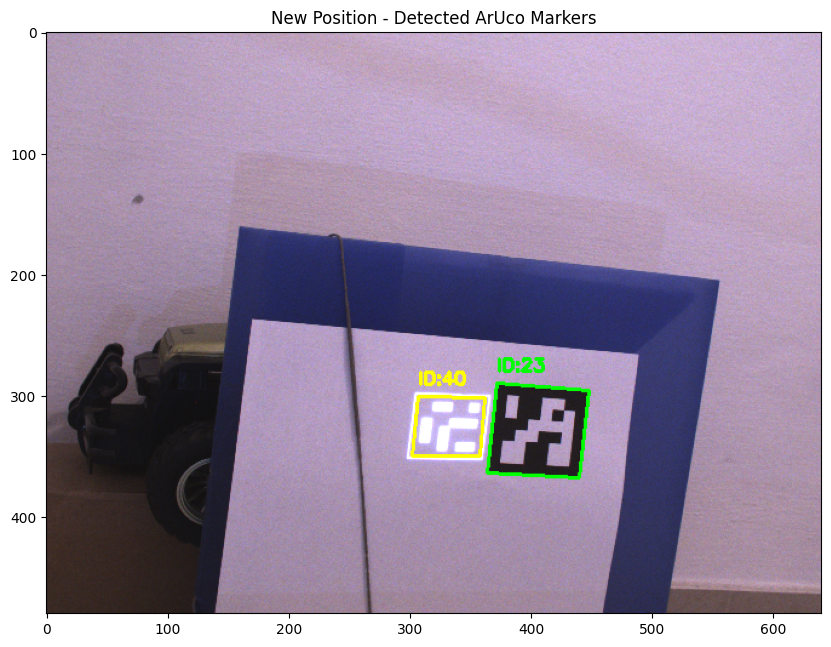

In [106]:
# Capture new frame after moving the printed ArUco
ret, frame_new = system.cap.read()
gray_new = cv2.cvtColor(frame_new, cv2.COLOR_BGR2GRAY)
corners_new, ids_new, _ = detector.detectMarkers(gray_new)

print(f"Detected marker IDs after move: {ids_new.flatten() if ids_new is not None else 'None'}")

# Get new corners for printed marker (projected marker might not be visible or in wrong position now)
camera_corners_new = {
    'printed': get_marker_corners(corners_new, ids_new, printed_aruco_id),
    'projected': get_marker_corners(corners_new, ids_new, projected_aruco_id)
}

print("\nNew Printed ArUco (23) corners in camera space:")
print(camera_corners_new['printed'])

# Visualize
frame_viz_new = frame_new.copy()
if ids_new is not None:
    for marker_id, corner_new in zip(ids_new.flatten(), corners_new):
        pts = corner_new.reshape((4, 2)).astype(int)
        color = (0, 255, 255) if marker_id == projected_aruco_id else (0, 255, 0)
        cv2.polylines(frame_viz_new, [pts], True, color, 2)
        cv2.putText(frame_viz_new, f"ID:{marker_id}", (pts[0][0], pts[0][1]-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(frame_viz_new, cv2.COLOR_BGR2RGB))
plt.title("New Position - Detected ArUco Markers")
plt.show()

In [107]:
# Compute the new homography for the printed marker
H_printed_new, _ = cv2.findHomography(marker_corners_img, camera_corners_new['printed'])

print("New Homography for Printed ArUco (marker space -> camera space):")
print(H_printed_new)

# Compute transformation from old camera position to new camera position for the printed marker
# T_camera_old_to_new = H_printed_new @ inv(H_printed)
# This tells us how the printed marker moved in camera space

T_camera_old_to_new = H_printed_new @ np.linalg.inv(H_printed)
print("\nTransformation from old to new printed marker position (in camera space):")
print(T_camera_old_to_new)

New Homography for Printed ArUco (marker space -> camera space):
[[ 8.83720930e-01 -6.94186047e-02  3.72000000e+02]
 [ 1.41744186e-01  7.50581395e-01  2.90000000e+02]
 [ 2.76162791e-04  2.90697674e-05  1.00000000e+00]]

Transformation from old to new printed marker position (in camera space):
[[ 1.01324633e+00  1.24305987e-03 -2.15013071e+01]
 [ 2.31392869e-05  9.99813526e-01 -9.54713981e-01]
 [ 6.87136721e-08 -5.11736290e-07  1.00012225e+00]]


In [108]:
# To maintain the same relative position, we need to compute where the projection 
# should be in camera space, given the new printed marker position.
#
# Original relationship: projected_camera = T_printed_to_projected_original @ printed_camera
# New desired projected position: new_projected_camera = T_printed_to_projected_original @ new_printed_camera
#
# The new projected marker corners in camera space should be:
H_projected_new = T_printed_to_projected_original @ H_printed_new

print("New desired Homography for Projected ArUco (to maintain relative position):")
print(H_projected_new)

# Transform the canonical marker corners to get the new desired projection position in camera space
projection_corners_in_camera = cv2.perspectiveTransform(
    marker_corners_img.reshape(1, -1, 2), 
    H_projected_new
).reshape(-1, 2)

print("\nNew desired projection corners in camera space:")
print(projection_corners_in_camera)

# For comparison, the original projection corners in camera space were:
original_projection_corners_in_camera = cv2.perspectiveTransform(
    marker_corners_img.reshape(1, -1, 2), 
    H_projected
).reshape(-1, 2)

print("\nOriginal projection corners in camera space:")
print(original_projection_corners_in_camera)

New desired Homography for Projected ArUco (to maintain relative position):
[[ 8.42745913e-01 -8.35719771e-02  2.90372819e+02]
 [ 2.10091401e-01  6.22188169e-01  2.92571605e+02]
 [ 5.34327543e-04  9.09727330e-05  9.94712294e-01]]

New desired projection corners in camera space:
[[291.91638 294.12686]
 [357.4385  299.17685]
 [346.45813 355.45264]
 [280.94534 353.44394]]

Original projection corners in camera space:
[[306. 295.]
 [370. 300.]
 [359. 356.]
 [295. 354.]]


In [109]:
# Now we need to transform these camera-space projection corners back to screen space
# We have: system.H maps from camera space to the cropped projection region
# We need to map from full screen space

# Get the crop region offset (top-left corner of projection region in screen coordinates)
orig_projection_region_corners = system.orig_proj_corners.astype(np.float32)
crop_top_left = orig_projection_region_corners[0]  # top-left corner in screen coords

# The projection region corners in the cropped image space (with border)
# system.img_non_zero_section_corners are the inner corners (after border)
# We need corners of the full projection region

# Homography from camera to cropped projection space
H_camera_to_screen = system.H  # This maps from camera to img_non_zero_section coordinates

# Transform camera corners to cropped projection space
projection_corners_in_crop = cv2.perspectiveTransform(
    projection_corners_in_camera.reshape(1, -1, 2).astype(np.float32),
    H_camera_to_screen
).reshape(-1, 2)

print("Projection corners in cropped space:")
print(projection_corners_in_crop)

# Convert to full screen coordinates by adding the crop offset
new_screen_corners = projection_corners_in_crop + crop_top_left

print("\nNew screen corners for projection:")
print(new_screen_corners)

print("\nOriginal screen corners were:")
print(original_screen_corners)

Projection corners in cropped space:
[[-56.63201  -24.048817]
 [186.4711    -8.733411]
 [168.48181  209.44505 ]
 [-68.15899  206.18419 ]]

New screen corners for projection:
[[1779.368  1689.9512]
 [2022.4711 1705.2666]
 [2004.4818 1923.4451]
 [1767.8411 1920.1842]]

Original screen corners were:
[[1836 1714]
 [2046 1714]
 [2046 1904]
 [1836 1904]]


In [110]:
# Alternative approach: Direct transformation on screen corners
# Instead of going through camera space, we can compute the transformation directly
# on screen coordinates by establishing the mapping between old and new positions

# Method: Find transformation from old camera corners to new camera corners for printed marker
# Then apply same transformation to the screen projection corners

# Homography from old printed corners to new printed corners (in camera space)
H_marker_to_screen = cv2.findHomography(
    original_camera_corners['printed'].astype(np.float32),
    camera_corners_new['printed'].astype(np.float32)
)[0]

# But we need transformation in screen space, not camera space
# Let's compute the full transformation chain:
# screen -> camera (inverse of display-to-capture mapping) -> transform -> camera -> screen

# For a more direct approach, we can use the relationship:
# new_screen = H_screen_transform @ old_screen
# where H_screen_transform accounts for the camera's view of the movement

# Using the camera transformation and projecting back:
H_camera_transform = H_printed_new @ np.linalg.inv(H_printed)  # old_camera -> new_camera for printed

# Transform original projection corners in camera space
orig_screen_corners = original_screen_corners.astype(np.float32)

# Map screen corners to camera space (using inverse of homography relationship)
# We need homography from screen to camera
orig_screen_corners_homog = np.hstack([orig_screen_corners, np.ones((4, 1))])

print("Transformation approach: using camera space as intermediate")
print(f"H_camera_transform shape: {H_camera_transform.shape}")

Transformation approach: using camera space as intermediate
H_camera_transform shape: (3, 3)


In [111]:
# Final method: Use the known correspondences to compute screen transformation
# 
# We know:
# 1. Original projected marker corners in camera space
# 2. We want the projection to follow the printed marker's movement
# 3. We can compute where the projection SHOULD appear in camera space
# 4. Using system.H, we can map back to screen space

# Step 1: Compute homography from screen corners to camera corners for projection
# Original: screen_corners -> (warp by projector) -> camera sees projected_aruco corners
H_screen_to_camera_projection = cv2.findHomography(
    orig_screen_corners,
    original_camera_corners['projected'].astype(np.float32)
)[0]

print("Homography from screen to camera (for projection):")
print(H_screen_to_camera_projection)

# Step 2: New desired camera corners for projection (maintaining relative position)
# = T_printed_to_projected_original @ new_printed_camera_corners
new_projected_camera_corners = cv2.perspectiveTransform(
    camera_corners_new['printed'].reshape(1, -1, 2).astype(np.float32),
    T_printed_to_projected_original
).reshape(-1, 2)

print("\nNew desired projection corners in camera space:")
print(new_projected_camera_corners)

# Step 3: Inverse transform to get new screen corners
H_camera_to_screen_projection = np.linalg.inv(H_screen_to_camera_projection)

new_screen_corners = cv2.perspectiveTransform(
    new_projected_camera_corners.reshape(1, -1, 2).astype(np.float32),
    H_camera_to_screen_projection
).reshape(-1, 2)

print("\nNew screen corners (computed):")
print(new_screen_corners)

print("\nOriginal screen corners:")
print(orig_screen_corners)

Homography from screen to camera (for projection):
[[ 8.81927778e-01 -9.66643137e-02 -7.76447865e+02]
 [ 2.20990371e-01  7.24832178e-01 -9.95351570e+02]
 [ 5.61022759e-04  1.06575870e-04  1.00000000e+00]]

New desired projection corners in camera space:
[[291.91638 294.12686]
 [357.4385  299.17685]
 [346.45813 355.45264]
 [280.94534 353.44394]]

New screen corners (computed):
[[1792.7327 1714.7067]
 [2003.1395 1714.5188]
 [2003.0173 1903.4768]
 [1792.6061 1903.6266]]

Original screen corners:
[[1836. 1714.]
 [2046. 1714.]
 [2046. 1904.]
 [1836. 1904.]]


Updated projection corners:
[[1792 1714]
 [2003 1714]
 [2003 1903]
 [1792 1903]]
Updated image shape: (2160, 3840)


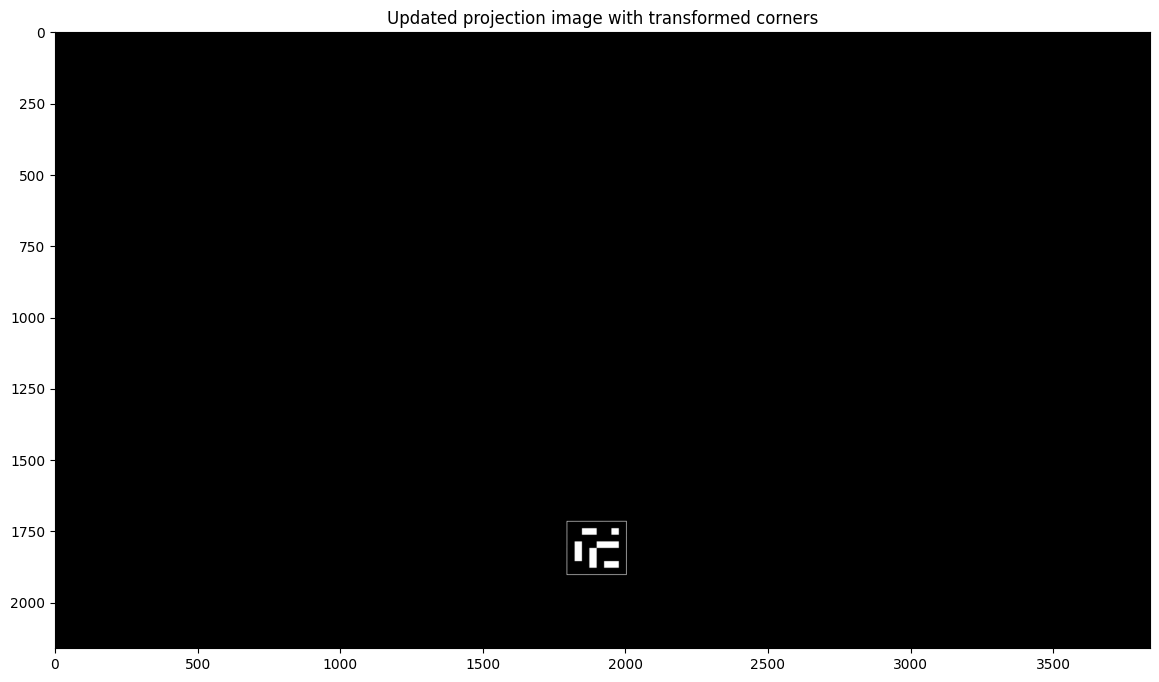

In [112]:
# Update system.orig_proj_corners with the new corners
rect_corners_updated = new_screen_corners.astype(np.int32)

print("Updated projection corners:")
print(rect_corners_updated)

# Create updated image to display
img_updated = np.zeros_like(system.img)

# Get bounding box of new corners
width_new = int(np.max(rect_corners_updated[:, 0]) - np.min(rect_corners_updated[:, 0]))
height_new = int(np.max(rect_corners_updated[:, 1]) - np.min(rect_corners_updated[:, 1]))

# Resize to_place to fit new region using perspective transform
src_corners = np.array([
    [0, 0],
    [system.to_place.shape[1], 0],
    [system.to_place.shape[1], system.to_place.shape[0]],
    [0, system.to_place.shape[0]]
], dtype=np.float32)

# Create perspective warp from source (to_place) to destination (new_screen_corners)
M = cv2.getPerspectiveTransform(src_corners, new_screen_corners.astype(np.float32))

# Apply perspective warp to to_place and place in img_updated
src_img = system.to_place if len(system.to_place.shape) == 3 else cv2.cvtColor(system.to_place, cv2.COLOR_GRAY2BGR)
if len(src_img.shape) == 2:
    src_img = cv2.cvtColor(src_img, cv2.COLOR_GRAY2BGR)

# Warp to_place into the full screen image
to_place_resized = cv2.warpPerspective(
    src_img, M, 
    (img_updated.shape[1], img_updated.shape[0])
)

# Convert to grayscale if needed
if len(img_updated.shape) == 2:
    to_place_resized = cv2.cvtColor(to_place_resized, cv2.COLOR_BGR2GRAY)
elif len(to_place_resized.shape) == 3 and len(img_updated.shape) == 2:
    to_place_resized = cv2.cvtColor(to_place_resized, cv2.COLOR_BGR2GRAY)

# Place the warped image
if len(img_updated.shape) == 2 and len(to_place_resized.shape) == 3:
    to_place_resized = cv2.cvtColor(to_place_resized, cv2.COLOR_BGR2GRAY)

img_updated = to_place_resized

print(f"Updated image shape: {img_updated.shape}")
plt.figure(figsize=(15, 8))
plt.imshow(img_updated, cmap='gray')
plt.title("Updated projection image with transformed corners")
plt.show()

In [113]:
# Display the updated projection
cv2.namedWindow("Rectangle Window", cv2.WND_PROP_FULLSCREEN)
cv2.setWindowProperty("Rectangle Window", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
cv2.imshow("Rectangle Window", img_updated)
wk = cv2.waitKey(10)
if wk == 27 or wk == 99:  # ESC key to exit or 'c' to capture
    cv2.destroyAllWindows()
    
print("Updated projection displayed!")

Updated projection displayed!


Verification - Detected markers: [23 40]

Original relative transformation (printed->projected):
[[ 9.77840627e-01 -1.82690444e-02 -6.80858712e+01]
 [ 9.94218168e-02  8.37646127e-01  1.26693122e+01]
 [ 3.23072609e-04  1.18544070e-04  8.40151503e-01]]

New relative transformation after update:
[[ 6.42556645e-01  1.91672927e-01 -4.61622099e+00]
 [-2.28254482e-01  1.01602197e+00  8.62642962e+01]
 [-6.81804758e-04  6.92375966e-04  1.05284234e+00]]

Max absolute difference: 73.5950
Mean absolute difference: 15.3700


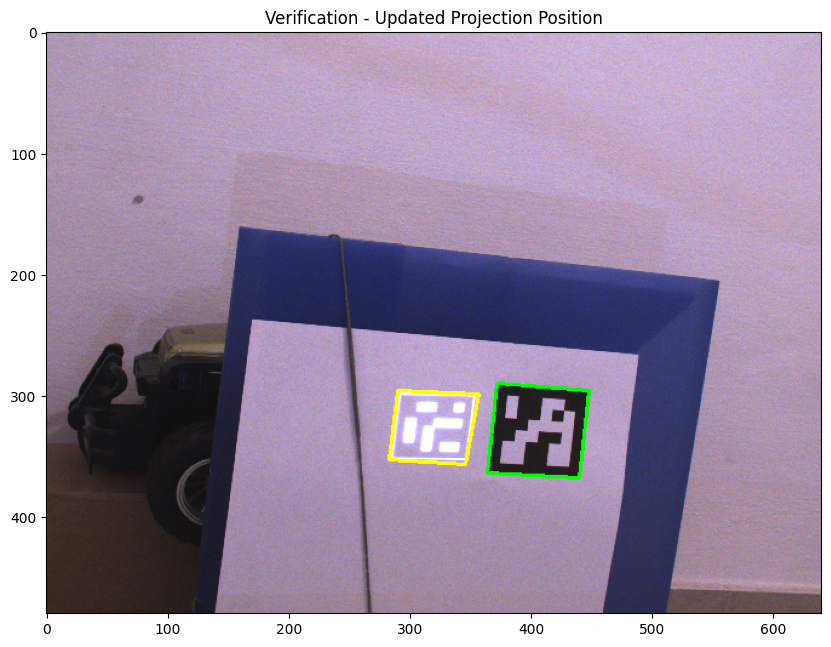

In [114]:
# Verification: Capture new frame and verify relative positions are maintained
import time
time.sleep(0.5)  # Wait for projection to update

ret, frame_test = system.cap.read()
gray_test = cv2.cvtColor(frame_test, cv2.COLOR_BGR2GRAY)
corners_test, ids_test, _ = detector.detectMarkers(gray_test)

print(f"Verification - Detected markers: {ids_test.flatten() if ids_test is not None else 'None'}")

# Get corners
if ids_test is not None:
    printed_corners_test = get_marker_corners(corners_test, ids_test, printed_aruco_id)
    projected_corners_test = get_marker_corners(corners_test, ids_test, projected_aruco_id)
    
    if printed_corners_test is not None and projected_corners_test is not None:
        # Compute new homographies
        H_printed_test, _ = cv2.findHomography(marker_corners_img, printed_corners_test)
        H_projected_test, _ = cv2.findHomography(marker_corners_img, projected_corners_test)
        
        # Compute relative transformation
        T_test = H_projected_test @ np.linalg.inv(H_printed_test)
        
        print("\nOriginal relative transformation (printed->projected):")
        print(T_printed_to_projected_original)
        
        print("\nNew relative transformation after update:")
        print(T_test)
        
        # Compute difference
        diff = np.abs(T_printed_to_projected_original - T_test)
        print(f"\nMax absolute difference: {np.max(diff):.4f}")
        print(f"Mean absolute difference: {np.mean(diff):.4f}")
    else:
        print("Could not detect both markers for verification")

# Visualize
frame_test_viz = frame_test.copy()
if ids_test is not None:
    for marker_id, corner in zip(ids_test.flatten(), corners_test):
        pts = corner.reshape((4, 2)).astype(int)
        color = (0, 255, 255) if marker_id == projected_aruco_id else (0, 255, 0)
        cv2.polylines(frame_test_viz, [pts], True, color, 2)
        
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(frame_test_viz, cv2.COLOR_BGR2RGB))
plt.title("Verification - Updated Projection Position")
plt.show()

## Summary: Homography-Based Tracking Function

The function below encapsulates the entire tracking logic to update the projection when the printed marker moves.

In [103]:
def compute_tracking_update(system, original_printed_corners, original_projected_corners, 
                            original_screen_corners, new_printed_corners, image_to_place):
    """
    Compute updated screen corners to maintain relative position between printed and projected markers.
    
    Args:
        system: CaptureSystem instance
        original_printed_corners: Original corners of printed ArUco in camera space (4x2)
        original_projected_corners: Original corners of projected ArUco in camera space (4x2)
        original_screen_corners: Original corners where projection is displayed on screen (4x2)
        new_printed_corners: New corners of printed ArUco in camera space after movement (4x2)
        image_to_place: Image to be projected (grayscale)
    
    Returns:
        updated_screen_image: New screen image with transformed projection
        new_screen_corners: Updated screen corners for the projection
    """
    # Canonical marker corners
    marker_size = 100
    marker_corners_img = np.array([
        [0, 0], [marker_size, 0], [marker_size, marker_size], [0, marker_size]
    ], dtype=np.float32)
    
    # Compute original homographies
    H_printed_orig, _ = cv2.findHomography(marker_corners_img, original_printed_corners)
    H_projected_orig, _ = cv2.findHomography(marker_corners_img, original_projected_corners)
    
    # Original relative transformation (printed -> projected in camera space)
    T_relative = H_projected_orig @ np.linalg.inv(H_printed_orig)
    
    # New homography for printed marker
    H_printed_new, _ = cv2.findHomography(marker_corners_img, new_printed_corners)
    
    # Homography from screen to camera for projection
    H_screen_to_camera = cv2.findHomography(
        original_screen_corners.astype(np.float32),
        original_projected_corners.astype(np.float32)
    )[0]
    
    # New desired camera corners for projection (maintaining relative position)
    new_projected_camera_corners = cv2.perspectiveTransform(
        new_printed_corners.reshape(1, -1, 2).astype(np.float32),
        T_relative
    ).reshape(-1, 2)
    
    # Transform back to screen space
    H_camera_to_screen = np.linalg.inv(H_screen_to_camera)
    new_screen_corners = cv2.perspectiveTransform(
        new_projected_camera_corners.reshape(1, -1, 2).astype(np.float32),
        H_camera_to_screen
    ).reshape(-1, 2)
    
    # Create updated screen image
    src_corners = np.array([
        [0, 0],
        [image_to_place.shape[1], 0],
        [image_to_place.shape[1], image_to_place.shape[0]],
        [0, image_to_place.shape[0]]
    ], dtype=np.float32)
    
    M = cv2.getPerspectiveTransform(src_corners, new_screen_corners.astype(np.float32))
    
    if len(image_to_place.shape) == 2:
        src_img = cv2.cvtColor(image_to_place, cv2.COLOR_GRAY2BGR)
    else:
        src_img = image_to_place
    
    updated_screen_image = cv2.warpPerspective(
        src_img, M, 
        (system.screen_res[0], system.screen_res[1])
    )
    
    if len(system.img.shape) == 2:
        updated_screen_image = cv2.cvtColor(updated_screen_image, cv2.COLOR_BGR2GRAY)
    
    return updated_screen_image, new_screen_corners, T_relative

print("Tracking function defined!")
print("\nUsage:")
print("updated_img, new_corners, T_rel = compute_tracking_update(")
print("    system,")
print("    original_printed_corners,")
print("    original_projected_corners,")
print("    original_screen_corners,")
print("    new_printed_corners,")
print("    system.to_place")
print(")")

Tracking function defined!

Usage:
updated_img, new_corners, T_rel = compute_tracking_update(
    system,
    original_printed_corners,
    original_projected_corners,
    original_screen_corners,
    new_printed_corners,
    system.to_place
)


## Real-Time Tracking Loop

Run the cell below to start real-time tracking. The projection will follow the printed ArUco marker as you move it.
- Press **'q'** to quit the loop
- Press **'r'** to reset/recalibrate the original positions

In [7]:
import time
import numpy as np
import cv2
def realtime_tracking_loop(system, printed_aruco_id=23, projected_aruco_id=40):
    """
    Real-time tracking loop that updates projection position as the printed ArUco moves.
    
    Press 'q' to quit, 'r' to reset/recalibrate original positions.
    """
    # Setup ArUco detector
    detectorParams = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(system.aruco_dict, detectorParams)
    
    # Helper function
    def get_marker_corners(corners, ids, target_id):
        if ids is None:
            return None
        idx = np.where(ids.flatten() == target_id)[0]
        if len(idx) == 0:
            return None
        return corners[idx[0]].reshape(4, 2)
    
    # Create fullscreen window for projection
    cv2.namedWindow("Projection", cv2.WND_PROP_FULLSCREEN)
    cv2.setWindowProperty("Projection", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
    
    # Create preview window
    cv2.namedWindow("Camera Preview", cv2.WINDOW_NORMAL)
    cv2.resizeWindow("Camera Preview", 800, 600)
    
    # Initial calibration - capture original positions
    print("Initializing... Detecting both markers for calibration...")
    
    original_printed_corners = None
    original_projected_corners = None
    original_screen_corners = system.orig_proj_corners.astype(np.float32)
    
    # Wait until both markers are detected
    while original_printed_corners is None or original_projected_corners is None:
        ret, frame = system.cap.read()
        if not ret:
            continue
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        corners, ids, _ = detector.detectMarkers(gray)
        
        original_printed_corners = get_marker_corners(corners, ids, printed_aruco_id)
        original_projected_corners = get_marker_corners(corners, ids, projected_aruco_id)
        
        # Show current frame
        frame_viz = frame.copy()
        if ids is not None:
            cv2.aruco.drawDetectedMarkers(frame_viz, corners, ids)
        cv2.putText(frame_viz, "Waiting for both markers...", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
        cv2.imshow("Camera Preview", frame_viz)
        cv2.imshow("Projection", system.img)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            cv2.destroyAllWindows()
            return
    
    print(f"Calibration complete!")
    print(f"Original printed corners:\n{original_printed_corners}")
    print(f"Original projected corners:\n{original_projected_corners}")
    
    # Compute the relative transformation (this stays constant)
    marker_size = 100
    marker_corners_img = np.array([
        [0, 0], [marker_size, 0], [marker_size, marker_size], [0, marker_size]
    ], dtype=np.float32)
    
    H_printed_orig, _ = cv2.findHomography(marker_corners_img, original_printed_corners)
    H_projected_orig, _ = cv2.findHomography(marker_corners_img, original_projected_corners)
    T_relative = H_projected_orig @ np.linalg.inv(H_printed_orig)
    
    # Homography from screen to camera
    H_screen_to_camera = cv2.findHomography(
        original_screen_corners,
        original_projected_corners.astype(np.float32)
    )[0]
    H_camera_to_screen = np.linalg.inv(H_screen_to_camera)
    
    # Current displayed image
    current_img = system.img.copy()
    
    # FPS calculation
    fps_start_time = time.time()
    frame_count = 0
    fps = 0
    
    print("\nReal-time tracking started!")
    print("Press 'q' to quit, 'r' to reset calibration")
    
    while True:
        ret, frame = system.cap.read()
        if not ret:
            continue
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        corners, ids, _ = detector.detectMarkers(gray)
        
        # Get current printed marker position
        current_printed_corners = get_marker_corners(corners, ids, printed_aruco_id)
        
        frame_viz = frame.copy()
        
        if current_printed_corners is not None:
            # Compute new projection position
            new_projected_camera_corners = cv2.perspectiveTransform(
                current_printed_corners.reshape(1, -1, 2).astype(np.float32),
                T_relative
            ).reshape(-1, 2)
            
            # Transform to screen space
            new_screen_corners = cv2.perspectiveTransform(
                new_projected_camera_corners.reshape(1, -1, 2).astype(np.float32),
                H_camera_to_screen
            ).reshape(-1, 2)
            
            # Create warped projection image
            src_corners = np.array([
                [0, 0],
                [system.to_place.shape[1], 0],
                [system.to_place.shape[1], system.to_place.shape[0]],
                [0, system.to_place.shape[0]]
            ], dtype=np.float32)
            
            M = cv2.getPerspectiveTransform(src_corners, new_screen_corners.astype(np.float32))
            
            if len(system.to_place.shape) == 2:
                src_img = cv2.cvtColor(system.to_place, cv2.COLOR_GRAY2BGR)
            else:
                src_img = system.to_place
            
            current_img = cv2.warpPerspective(
                src_img, M, 
                (system.screen_res[0], system.screen_res[1])
            )
            
            if len(system.img.shape) == 2:
                current_img = cv2.cvtColor(current_img, cv2.COLOR_BGR2GRAY)
            
            # Draw visualization on preview
            pts_printed = current_printed_corners.astype(int)
            cv2.polylines(frame_viz, [pts_printed], True, (0, 255, 0), 2)
            cv2.putText(frame_viz, f"Printed: {printed_aruco_id}", 
                        (pts_printed[0][0], pts_printed[0][1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            
            # Draw expected projection position
            pts_proj = new_projected_camera_corners.astype(int)
            cv2.polylines(frame_viz, [pts_proj], True, (0, 255, 255), 2)
            cv2.putText(frame_viz, f"Target Proj", 
                        (pts_proj[0][0], pts_proj[0][1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
            
            status = "TRACKING"
            status_color = (0, 255, 0)
        else:
            status = "LOST - Looking for printed marker..."
            status_color = (0, 0, 255)
        
        # Draw detected projected marker if visible
        current_projected_corners = get_marker_corners(corners, ids, projected_aruco_id)
        if current_projected_corners is not None:
            pts_actual = current_projected_corners.astype(int)
            cv2.polylines(frame_viz, [pts_actual], True, (255, 0, 255), 2)
            cv2.putText(frame_viz, f"Actual Proj: {projected_aruco_id}", 
                        (pts_actual[0][0], pts_actual[0][1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 255), 2)
        
        # FPS calculation
        frame_count += 1
        elapsed = time.time() - fps_start_time
        if elapsed >= 1.0:
            fps = frame_count / elapsed
            frame_count = 0
            fps_start_time = time.time()
        
        # Draw status and FPS
        cv2.putText(frame_viz, f"Status: {status}", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_color, 2)
        cv2.putText(frame_viz, f"FPS: {fps:.1f}", (10, 60), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.putText(frame_viz, "Press 'q' to quit, 'r' to reset", (10, 90), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        
        # Display
        cv2.imshow("Projection", current_img)
        cv2.imshow("Camera Preview", frame_viz)
        
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('r'):
            # Reset calibration
            print("\nResetting calibration...")
            original_printed_corners = current_printed_corners
            current_projected = get_marker_corners(corners, ids, projected_aruco_id)
            if current_projected is not None:
                original_projected_corners = current_projected
                original_screen_corners = system.orig_proj_corners.astype(np.float32)
                
                # Recompute transformations
                H_printed_orig, _ = cv2.findHomography(marker_corners_img, original_printed_corners)
                H_projected_orig, _ = cv2.findHomography(marker_corners_img, original_projected_corners)
                T_relative = H_projected_orig @ np.linalg.inv(H_printed_orig)
                
                H_screen_to_camera = cv2.findHomography(
                    original_screen_corners,
                    original_projected_corners.astype(np.float32)
                )[0]
                H_camera_to_screen = np.linalg.inv(H_screen_to_camera)
                
                print("Calibration reset complete!")
            else:
                print("Cannot reset - projected marker not visible!")
    
    cv2.destroyAllWindows()
    print("\nTracking loop ended.")

print("Real-time tracking function defined!")
print("\nRun: realtime_tracking_loop(system)")
print("Or with custom marker IDs: realtime_tracking_loop(system, printed_aruco_id=23, projected_aruco_id=40)")

Real-time tracking function defined!

Run: realtime_tracking_loop(system)
Or with custom marker IDs: realtime_tracking_loop(system, printed_aruco_id=23, projected_aruco_id=40)


In [8]:
# Start the real-time tracking loop
# Press 'q' to quit, 'r' to reset calibration
realtime_tracking_loop(system)

Initializing... Detecting both markers for calibration...
Calibration complete!
Original printed corners:
[[408. 274.]
 [490. 283.]
 [478. 358.]
 [394. 350.]]
Original projected corners:
[[298. 272.]
 [347. 275.]
 [341. 312.]
 [293. 309.]]

Real-time tracking started!
Press 'q' to quit, 'r' to reset calibration
Calibration complete!
Original printed corners:
[[408. 274.]
 [490. 283.]
 [478. 358.]
 [394. 350.]]
Original projected corners:
[[298. 272.]
 [347. 275.]
 [341. 312.]
 [293. 309.]]

Real-time tracking started!
Press 'q' to quit, 'r' to reset calibration

Tracking loop ended.

Tracking loop ended.


## Real-Time Tracking with Rotation Support

This version tracks both translation AND rotation of the printed ArUco marker, updating the projection to match the full pose transformation.

In [11]:
import time
import numpy as np
import cv2

def realtime_tracking_loop_with_rotation(system, printed_aruco_id=23, projected_aruco_id=40):
    """
    Real-time tracking loop that updates projection position AND rotation 
    as the printed ArUco moves and rotates.
    
    This version properly handles rotation by computing a full homography transformation
    that captures both translation and rotation of the printed marker.
    
    Press 'q' to quit, 'r' to reset/recalibrate original positions.
    """
    # Setup ArUco detector
    detectorParams = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(system.aruco_dict, detectorParams)
    
    # Helper function
    def get_marker_corners(corners, ids, target_id):
        if ids is None:
            return None
        idx = np.where(ids.flatten() == target_id)[0]
        if len(idx) == 0:
            return None
        return corners[idx[0]].reshape(4, 2)
    
    def compute_marker_pose(corners):
        """
        Compute pose information from marker corners.
        Returns center, rotation angle, and scale.
        """
        center = np.mean(corners, axis=0)
        
        # Compute rotation from the first edge (top edge of marker)
        edge_vec = corners[1] - corners[0]
        angle = np.arctan2(edge_vec[1], edge_vec[0])
        
        # Compute scale (average side length)
        side1 = np.linalg.norm(corners[1] - corners[0])
        side2 = np.linalg.norm(corners[2] - corners[1])
        scale = (side1 + side2) / 2
        
        return center, angle, scale
    
    def compute_relative_transform(printed_corners, projected_corners):
        """
        Compute the relative transformation between printed and projected markers.
        Returns offset vector, relative rotation, and relative scale.
        """
        p_center, p_angle, p_scale = compute_marker_pose(printed_corners)
        proj_center, proj_angle, proj_scale = compute_marker_pose(projected_corners)
        
        # Offset in the printed marker's local coordinate frame
        # Rotate the offset vector by negative printed angle to get local offset
        offset_world = proj_center - p_center
        cos_a, sin_a = np.cos(-p_angle), np.sin(-p_angle)
        offset_local = np.array([
            offset_world[0] * cos_a - offset_world[1] * sin_a,
            offset_world[0] * sin_a + offset_world[1] * cos_a
        ])
        
        # Relative rotation (projected angle relative to printed angle)
        relative_angle = proj_angle - p_angle
        
        # Relative scale
        relative_scale = proj_scale / p_scale if p_scale > 0 else 1.0
        
        return offset_local, relative_angle, relative_scale
    
    def apply_relative_transform(printed_corners, offset_local, relative_angle, relative_scale):
        """
        Apply the stored relative transformation to compute new projected position.
        """
        p_center, p_angle, p_scale = compute_marker_pose(printed_corners)
        
        # New projected angle = printed angle + relative angle
        new_proj_angle = p_angle + relative_angle
        
        # New projected scale = printed scale * relative scale
        new_proj_scale = p_scale * relative_scale
        
        # Transform local offset back to world coordinates using current printed angle
        cos_a, sin_a = np.cos(p_angle), np.sin(p_angle)
        offset_world = np.array([
            offset_local[0] * cos_a - offset_local[1] * sin_a,
            offset_local[0] * sin_a + offset_local[1] * cos_a
        ])
        
        # New projected center
        new_proj_center = p_center + offset_world
        
        # Generate new projected corners
        # Create canonical square centered at origin, then transform
        half_size = new_proj_scale / 2
        canonical_corners = np.array([
            [-half_size, -half_size],
            [half_size, -half_size],
            [half_size, half_size],
            [-half_size, half_size]
        ], dtype=np.float32)
        
        # Rotate by new_proj_angle
        cos_r, sin_r = np.cos(new_proj_angle), np.sin(new_proj_angle)
        rotation_matrix = np.array([[cos_r, -sin_r], [sin_r, cos_r]])
        rotated_corners = canonical_corners @ rotation_matrix.T
        
        # Translate to new center
        new_proj_corners = rotated_corners + new_proj_center
        
        return new_proj_corners
    
    # Create fullscreen window for projection
    cv2.namedWindow("Projection", cv2.WND_PROP_FULLSCREEN)
    cv2.setWindowProperty("Projection", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
    
    # Create preview window
    cv2.namedWindow("Camera Preview", cv2.WINDOW_NORMAL)
    cv2.resizeWindow("Camera Preview", 800, 600)
    
    # Initial calibration - capture original positions
    print("Initializing... Detecting both markers for calibration...")
    
    original_printed_corners = None
    original_projected_corners = None
    original_screen_corners = system.orig_proj_corners.astype(np.float32)
    
    # Wait until both markers are detected
    while original_printed_corners is None or original_projected_corners is None:
        ret, frame = system.cap.read()
        if not ret:
            continue
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        corners, ids, _ = detector.detectMarkers(gray)
        
        original_printed_corners = get_marker_corners(corners, ids, printed_aruco_id)
        original_projected_corners = get_marker_corners(corners, ids, projected_aruco_id)
        
        # Show current frame
        frame_viz = frame.copy()
        if ids is not None:
            cv2.aruco.drawDetectedMarkers(frame_viz, corners, ids)
        cv2.putText(frame_viz, "Waiting for both markers...", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
        cv2.imshow("Camera Preview", frame_viz)
        cv2.imshow("Projection", system.img)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            cv2.destroyAllWindows()
            return
    
    print(f"Calibration complete!")
    print(f"Original printed corners:\n{original_printed_corners}")
    print(f"Original projected corners:\n{original_projected_corners}")
    
    # Compute the relative transformation (offset, rotation, scale)
    offset_local, relative_angle, relative_scale = compute_relative_transform(
        original_printed_corners, original_projected_corners
    )
    
    print(f"\nRelative transformation:")
    print(f"  Local offset: {offset_local}")
    print(f"  Relative angle: {np.degrees(relative_angle):.2f} degrees")
    print(f"  Relative scale: {relative_scale:.3f}")
    
    # Homography from screen to camera (for projecting back to screen space)
    H_screen_to_camera = cv2.findHomography(
        original_screen_corners,
        original_projected_corners.astype(np.float32)
    )[0]
    H_camera_to_screen = np.linalg.inv(H_screen_to_camera)
    
    # Current displayed image
    current_img = system.img.copy()
    
    # FPS calculation
    fps_start_time = time.time()
    frame_count = 0
    fps = 0
    
    print("\nReal-time tracking with rotation started!")
    print("Press 'q' to quit, 'r' to reset calibration")
    
    while True:
        ret, frame = system.cap.read()
        if not ret:
            continue
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        corners, ids, _ = detector.detectMarkers(gray)
        
        # Get current printed marker position
        current_printed_corners = get_marker_corners(corners, ids, printed_aruco_id)
        
        frame_viz = frame.copy()
        
        if current_printed_corners is not None:
            # Compute new projection position using relative transform
            new_projected_camera_corners = apply_relative_transform(
                current_printed_corners, offset_local, relative_angle, relative_scale
            )
            
            # Transform to screen space
            new_screen_corners = cv2.perspectiveTransform(
                new_projected_camera_corners.reshape(1, -1, 2).astype(np.float32),
                H_camera_to_screen
            ).reshape(-1, 2)
            
            # Create warped projection image
            src_corners = np.array([
                [0, 0],
                [system.to_place.shape[1], 0],
                [system.to_place.shape[1], system.to_place.shape[0]],
                [0, system.to_place.shape[0]]
            ], dtype=np.float32)
            
            M = cv2.getPerspectiveTransform(src_corners, new_screen_corners.astype(np.float32))
            
            if len(system.to_place.shape) == 2:
                src_img = cv2.cvtColor(system.to_place, cv2.COLOR_GRAY2BGR)
            else:
                src_img = system.to_place
            
            current_img = cv2.warpPerspective(
                src_img, M, 
                (system.screen_res[0], system.screen_res[1])
            )
            
            if len(system.img.shape) == 2:
                current_img = cv2.cvtColor(current_img, cv2.COLOR_BGR2GRAY)
            
            # Draw visualization on preview
            pts_printed = current_printed_corners.astype(int)
            cv2.polylines(frame_viz, [pts_printed], True, (0, 255, 0), 2)
            
            # Draw orientation arrow for printed marker
            p_center, p_angle, _ = compute_marker_pose(current_printed_corners)
            arrow_end = p_center + 40 * np.array([np.cos(p_angle), np.sin(p_angle)])
            cv2.arrowedLine(frame_viz, tuple(p_center.astype(int)), 
                           tuple(arrow_end.astype(int)), (0, 255, 0), 2)
            cv2.putText(frame_viz, f"Printed: {printed_aruco_id}", 
                        (pts_printed[0][0], pts_printed[0][1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            
            # Draw expected projection position with orientation
            pts_proj = new_projected_camera_corners.astype(int)
            cv2.polylines(frame_viz, [pts_proj], True, (0, 255, 255), 2)
            
            proj_center, proj_angle, _ = compute_marker_pose(new_projected_camera_corners)
            arrow_end_proj = proj_center + 40 * np.array([np.cos(proj_angle), np.sin(proj_angle)])
            cv2.arrowedLine(frame_viz, tuple(proj_center.astype(int)), 
                           tuple(arrow_end_proj.astype(int)), (0, 255, 255), 2)
            cv2.putText(frame_viz, f"Target Proj", 
                        (pts_proj[0][0], pts_proj[0][1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
            
            # Display rotation info
            rotation_deg = np.degrees(p_angle)
            cv2.putText(frame_viz, f"Rotation: {rotation_deg:.1f} deg", (10, 120), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
            
            status = "TRACKING (with rotation)"
            status_color = (0, 255, 0)
        else:
            status = "LOST - Looking for printed marker..."
            status_color = (0, 0, 255)
        
        # Draw detected projected marker if visible
        current_projected_corners = get_marker_corners(corners, ids, projected_aruco_id)
        if current_projected_corners is not None:
            pts_actual = current_projected_corners.astype(int)
            cv2.polylines(frame_viz, [pts_actual], True, (255, 0, 255), 2)
            cv2.putText(frame_viz, f"Actual Proj: {projected_aruco_id}", 
                        (pts_actual[0][0], pts_actual[0][1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 255), 2)
        
        # FPS calculation
        frame_count += 1
        elapsed = time.time() - fps_start_time
        if elapsed >= 1.0:
            fps = frame_count / elapsed
            frame_count = 0
            fps_start_time = time.time()
        
        # Draw status and FPS
        cv2.putText(frame_viz, f"Status: {status}", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_color, 2)
        cv2.putText(frame_viz, f"FPS: {fps:.1f}", (10, 60), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.putText(frame_viz, "Press 'q' to quit, 'r' to reset", (10, 90), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        
        # Display
        cv2.imshow("Projection", current_img)
        cv2.imshow("Camera Preview", frame_viz)
        
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('r'):
            # Reset calibration
            print("\nResetting calibration...")
            original_printed_corners = current_printed_corners
            current_projected = get_marker_corners(corners, ids, projected_aruco_id)
            if current_projected is not None and original_printed_corners is not None:
                original_projected_corners = current_projected
                original_screen_corners = system.orig_proj_corners.astype(np.float32)
                
                # Recompute relative transformation
                offset_local, relative_angle, relative_scale = compute_relative_transform(
                    original_printed_corners, original_projected_corners
                )
                
                H_screen_to_camera = cv2.findHomography(
                    original_screen_corners,
                    original_projected_corners.astype(np.float32)
                )[0]
                H_camera_to_screen = np.linalg.inv(H_screen_to_camera)
                
                print(f"Calibration reset complete!")
                print(f"  Local offset: {offset_local}")
                print(f"  Relative angle: {np.degrees(relative_angle):.2f} degrees")
                print(f"  Relative scale: {relative_scale:.3f}")
            else:
                print("Cannot reset - need both markers visible!")
    
    cv2.destroyAllWindows()
    print("\nTracking loop ended.")

print("Real-time tracking with rotation function defined!")
print("\nRun: realtime_tracking_loop_with_rotation(system)")

Real-time tracking with rotation function defined!

Run: realtime_tracking_loop_with_rotation(system)


In [12]:
# Start the real-time tracking loop WITH rotation support
# Press 'q' to quit, 'r' to reset calibration
realtime_tracking_loop_with_rotation(system)

Initializing... Detecting both markers for calibration...
Calibration complete!
Original printed corners:
[[369. 275.]
 [456. 286.]
 [441. 364.]
 [354. 353.]]
Original projected corners:
[[294. 274.]
 [352. 279.]
 [346. 324.]
 [289. 322.]]

Relative transformation:
  Local offset: [-86.558     -8.963124]
  Relative angle: -2.28 degrees
  Relative scale: 0.620

Real-time tracking with rotation started!
Press 'q' to quit, 'r' to reset calibration

Resetting calibration...
Calibration reset complete!
  Local offset: [-86.17399   -9.723336]
  Relative angle: -2.24 degrees
  Relative scale: 0.619

Resetting calibration...
Calibration reset complete!
  Local offset: [-84.663826 -11.910087]
  Relative angle: -2.24 degrees
  Relative scale: 0.576

Tracking loop ended.


## Debugging Version - Monitor Desired vs Actual Projection

This version monitors the error between desired projection position and actual detected projection. It will break and save debug info when the error exceeds a threshold.

In [ ]:
import time
import numpy as np
import cv2

def realtime_tracking_debug(system, printed_aruco_id=23, projected_aruco_id=40, 
                            error_threshold=30.0, angle_error_threshold=15.0):
    """
    Debug version of tracking loop that monitors desired vs actual projection.
    Breaks when error exceeds threshold and returns debug info.
    
    Args:
        error_threshold: Max allowed center distance error in pixels
        angle_error_threshold: Max allowed angle error in degrees
    
    Returns dict with debug info when error threshold exceeded.
    """
    # Setup ArUco detector
    detectorParams = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(system.aruco_dict, detectorParams)
    
    # Helper functions
    def get_marker_corners(corners, ids, target_id):
        if ids is None:
            return None
        idx = np.where(ids.flatten() == target_id)[0]
        if len(idx) == 0:
            return None
        return corners[idx[0]].reshape(4, 2)
    
    def compute_marker_pose(corners):
        """Compute center, rotation angle, and scale from corners."""
        center = np.mean(corners, axis=0)
        edge_vec = corners[1] - corners[0]
        angle = np.arctan2(edge_vec[1], edge_vec[0])
        side1 = np.linalg.norm(corners[1] - corners[0])
        side2 = np.linalg.norm(corners[2] - corners[1])
        scale = (side1 + side2) / 2
        return center, angle, scale
    
    def compute_relative_transform(printed_corners, projected_corners):
        """Compute relative transformation between markers."""
        p_center, p_angle, p_scale = compute_marker_pose(printed_corners)
        proj_center, proj_angle, proj_scale = compute_marker_pose(projected_corners)
        
        offset_world = proj_center - p_center
        cos_a, sin_a = np.cos(-p_angle), np.sin(-p_angle)
        offset_local = np.array([
            offset_world[0] * cos_a - offset_world[1] * sin_a,
            offset_world[0] * sin_a + offset_world[1] * cos_a
        ])
        relative_angle = proj_angle - p_angle
        relative_scale = proj_scale / p_scale if p_scale > 0 else 1.0
        
        return offset_local, relative_angle, relative_scale
    
    def apply_relative_transform(printed_corners, offset_local, relative_angle, relative_scale):
        """Apply stored relative transformation to compute new projected position."""
        p_center, p_angle, p_scale = compute_marker_pose(printed_corners)
        
        new_proj_angle = p_angle + relative_angle
        new_proj_scale = p_scale * relative_scale
        
        cos_a, sin_a = np.cos(p_angle), np.sin(p_angle)
        offset_world = np.array([
            offset_local[0] * cos_a - offset_local[1] * sin_a,
            offset_local[0] * sin_a + offset_local[1] * cos_a
        ])
        
        new_proj_center = p_center + offset_world
        
        half_size = new_proj_scale / 2
        canonical_corners = np.array([
            [-half_size, -half_size],
            [half_size, -half_size],
            [half_size, half_size],
            [-half_size, half_size]
        ], dtype=np.float32)
        
        cos_r, sin_r = np.cos(new_proj_angle), np.sin(new_proj_angle)
        rotation_matrix = np.array([[cos_r, -sin_r], [sin_r, cos_r]])
        rotated_corners = canonical_corners @ rotation_matrix.T
        new_proj_corners = rotated_corners + new_proj_center
        
        return new_proj_corners
    
    def compute_error(desired_corners, actual_corners):
        """Compute error metrics between desired and actual corners."""
        # Center error
        desired_center = np.mean(desired_corners, axis=0)
        actual_center = np.mean(actual_corners, axis=0)
        center_error = np.linalg.norm(desired_center - actual_center)
        
        # Angle error
        desired_edge = desired_corners[1] - desired_corners[0]
        actual_edge = actual_corners[1] - actual_corners[0]
        desired_angle = np.arctan2(desired_edge[1], desired_edge[0])
        actual_angle = np.arctan2(actual_edge[1], actual_edge[0])
        angle_error = np.abs(np.degrees(desired_angle - actual_angle))
        # Normalize to [-180, 180]
        if angle_error > 180:
            angle_error = 360 - angle_error
        
        # Corner-wise error
        corner_errors = np.linalg.norm(desired_corners - actual_corners, axis=1)
        max_corner_error = np.max(corner_errors)
        mean_corner_error = np.mean(corner_errors)
        
        return {
            'center_error': center_error,
            'angle_error': angle_error,
            'max_corner_error': max_corner_error,
            'mean_corner_error': mean_corner_error,
            'corner_errors': corner_errors
        }
    
    # Create windows
    cv2.namedWindow("Projection", cv2.WND_PROP_FULLSCREEN)
    cv2.setWindowProperty("Projection", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
    cv2.namedWindow("Camera Preview", cv2.WINDOW_NORMAL)
    cv2.resizeWindow("Camera Preview", 800, 600)
    
    print("Initializing... Detecting both markers for calibration...")
    
    original_printed_corners = None
    original_projected_corners = None
    original_screen_corners = system.orig_proj_corners.astype(np.float32)
    
    # Wait for both markers
    while original_printed_corners is None or original_projected_corners is None:
        ret, frame = system.cap.read()
        if not ret:
            continue
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        corners, ids, _ = detector.detectMarkers(gray)
        
        original_printed_corners = get_marker_corners(corners, ids, printed_aruco_id)
        original_projected_corners = get_marker_corners(corners, ids, projected_aruco_id)
        
        frame_viz = frame.copy()
        if ids is not None:
            cv2.aruco.drawDetectedMarkers(frame_viz, corners, ids)
        cv2.putText(frame_viz, "Waiting for both markers...", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
        cv2.imshow("Camera Preview", frame_viz)
        cv2.imshow("Projection", system.img)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            cv2.destroyAllWindows()
            return None
    
    print(f"Calibration complete!")
    print(f"Original printed corners:\n{original_printed_corners}")
    print(f"Original projected corners:\n{original_projected_corners}")
    
    # Compute relative transformation
    offset_local, relative_angle, relative_scale = compute_relative_transform(
        original_printed_corners, original_projected_corners
    )
    
    print(f"\nRelative transformation:")
    print(f"  Local offset: {offset_local}")
    print(f"  Relative angle: {np.degrees(relative_angle):.2f} degrees")
    print(f"  Relative scale: {relative_scale:.3f}")
    
    # Homography from screen to camera
    H_screen_to_camera = cv2.findHomography(
        original_screen_corners,
        original_projected_corners.astype(np.float32)
    )[0]
    H_camera_to_screen = np.linalg.inv(H_screen_to_camera)
    
    current_img = system.img.copy()
    fps_start_time = time.time()
    frame_count = 0
    fps = 0
    
    # Error history for plotting
    error_history = []
    
    print(f"\nDebug tracking started!")
    print(f"Error threshold: {error_threshold} px, Angle threshold: {angle_error_threshold} deg")
    print("Press 'q' to quit, 'r' to reset")
    
    debug_info = None
    
    while True:
        ret, frame = system.cap.read()
        if not ret:
            continue
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        corners, ids, _ = detector.detectMarkers(gray)
        
        current_printed_corners = get_marker_corners(corners, ids, printed_aruco_id)
        current_projected_corners = get_marker_corners(corners, ids, projected_aruco_id)
        
        frame_viz = frame.copy()
        
        if current_printed_corners is not None:
            # Compute desired projection position
            desired_proj_corners = apply_relative_transform(
                current_printed_corners, offset_local, relative_angle, relative_scale
            )
            
            # Transform to screen space
            new_screen_corners = cv2.perspectiveTransform(
                desired_proj_corners.reshape(1, -1, 2).astype(np.float32),
                H_camera_to_screen
            ).reshape(-1, 2)
            
            # Update projection
            src_corners = np.array([
                [0, 0],
                [system.to_place.shape[1], 0],
                [system.to_place.shape[1], system.to_place.shape[0]],
                [0, system.to_place.shape[0]]
            ], dtype=np.float32)
            
            M = cv2.getPerspectiveTransform(src_corners, new_screen_corners.astype(np.float32))
            
            if len(system.to_place.shape) == 2:
                src_img = cv2.cvtColor(system.to_place, cv2.COLOR_GRAY2BGR)
            else:
                src_img = system.to_place
            
            current_img = cv2.warpPerspective(
                src_img, M, 
                (system.screen_res[0], system.screen_res[1])
            )
            
            if len(system.img.shape) == 2:
                current_img = cv2.cvtColor(current_img, cv2.COLOR_BGR2GRAY)
            
            # Draw printed marker (green)
            pts_printed = current_printed_corners.astype(int)
            cv2.polylines(frame_viz, [pts_printed], True, (0, 255, 0), 2)
            p_center, p_angle, _ = compute_marker_pose(current_printed_corners)
            arrow_end = p_center + 40 * np.array([np.cos(p_angle), np.sin(p_angle)])
            cv2.arrowedLine(frame_viz, tuple(p_center.astype(int)), 
                           tuple(arrow_end.astype(int)), (0, 255, 0), 2)
            
            # Draw DESIRED projection (yellow)
            pts_desired = desired_proj_corners.astype(int)
            cv2.polylines(frame_viz, [pts_desired], True, (0, 255, 255), 2)
            desired_center, desired_angle, _ = compute_marker_pose(desired_proj_corners)
            arrow_end_d = desired_center + 40 * np.array([np.cos(desired_angle), np.sin(desired_angle)])
            cv2.arrowedLine(frame_viz, tuple(desired_center.astype(int)), 
                           tuple(arrow_end_d.astype(int)), (0, 255, 255), 2)
            cv2.putText(frame_viz, "DESIRED", (pts_desired[0][0], pts_desired[0][1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
            
            # Check if actual projection is detected and compute error
            if current_projected_corners is not None:
                # Draw ACTUAL projection (magenta)
                pts_actual = current_projected_corners.astype(int)
                cv2.polylines(frame_viz, [pts_actual], True, (255, 0, 255), 2)
                actual_center, actual_angle, _ = compute_marker_pose(current_projected_corners)
                arrow_end_a = actual_center + 40 * np.array([np.cos(actual_angle), np.sin(actual_angle)])
                cv2.arrowedLine(frame_viz, tuple(actual_center.astype(int)), 
                               tuple(arrow_end_a.astype(int)), (255, 0, 255), 2)
                cv2.putText(frame_viz, "ACTUAL", (pts_actual[0][0], pts_actual[0][1]-25),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 255), 2)
                
                # Compute error
                errors = compute_error(desired_proj_corners, current_projected_corners)
                error_history.append(errors)
                
                # Draw error line between centers
                cv2.line(frame_viz, tuple(desired_center.astype(int)), 
                        tuple(actual_center.astype(int)), (0, 0, 255), 2)
                
                # Display error metrics
                cv2.putText(frame_viz, f"Center Error: {errors['center_error']:.1f} px", 
                           (10, 150), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
                cv2.putText(frame_viz, f"Angle Error: {errors['angle_error']:.1f} deg", 
                           (10, 170), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
                cv2.putText(frame_viz, f"Max Corner Error: {errors['max_corner_error']:.1f} px", 
                           (10, 190), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
                
                # Check threshold
                if errors['center_error'] > error_threshold or errors['angle_error'] > angle_error_threshold:
                    print(f"\n*** ERROR THRESHOLD EXCEEDED ***")
                    print(f"Center error: {errors['center_error']:.2f} px (threshold: {error_threshold})")
                    print(f"Angle error: {errors['angle_error']:.2f} deg (threshold: {angle_error_threshold})")
                    
                    debug_info = {
                        'frame': frame.copy(),
                        'frame_viz': frame_viz.copy(),
                        'printed_corners': current_printed_corners.copy(),
                        'desired_proj_corners': desired_proj_corners.copy(),
                        'actual_proj_corners': current_projected_corners.copy(),
                        'errors': errors,
                        'error_history': error_history,
                        'offset_local': offset_local,
                        'relative_angle': relative_angle,
                        'relative_scale': relative_scale,
                        'original_printed_corners': original_printed_corners,
                        'original_projected_corners': original_projected_corners,
                        'H_screen_to_camera': H_screen_to_camera,
                        'H_camera_to_screen': H_camera_to_screen
                    }
                    
                    # Show the error frame
                    cv2.putText(frame_viz, "ERROR THRESHOLD EXCEEDED!", (10, 250), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 3)
                    cv2.imshow("Camera Preview", frame_viz)
                    cv2.waitKey(0)  # Wait for key press
                    break
                
                status = f"TRACKING - Err: {errors['center_error']:.1f}px, {errors['angle_error']:.1f}deg"
                status_color = (0, 255, 0)
            else:
                status = "TRACKING (projection not detected)"
                status_color = (255, 255, 0)
            
            # Display rotation info
            rotation_deg = np.degrees(p_angle)
            cv2.putText(frame_viz, f"Printed Rotation: {rotation_deg:.1f} deg", (10, 120), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
        else:
            status = "LOST - Looking for printed marker..."
            status_color = (0, 0, 255)
        
        # FPS
        frame_count += 1
        elapsed = time.time() - fps_start_time
        if elapsed >= 1.0:
            fps = frame_count / elapsed
            frame_count = 0
            fps_start_time = time.time()
        
        cv2.putText(frame_viz, f"Status: {status}", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, status_color, 2)
        cv2.putText(frame_viz, f"FPS: {fps:.1f}", (10, 60), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.putText(frame_viz, "Press 'q' to quit, 'r' to reset", (10, 90), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        
        cv2.imshow("Projection", current_img)
        cv2.imshow("Camera Preview", frame_viz)
        
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('r'):
            print("\nResetting calibration...")
            original_printed_corners = current_printed_corners
            if current_projected_corners is not None and original_printed_corners is not None:
                original_projected_corners = current_projected_corners
                original_screen_corners = system.orig_proj_corners.astype(np.float32)
                
                offset_local, relative_angle, relative_scale = compute_relative_transform(
                    original_printed_corners, original_projected_corners
                )
                
                H_screen_to_camera = cv2.findHomography(
                    original_screen_corners,
                    original_projected_corners.astype(np.float32)
                )[0]
                H_camera_to_screen = np.linalg.inv(H_screen_to_camera)
                
                error_history = []  # Clear error history
                
                print(f"Calibration reset!")
                print(f"  Local offset: {offset_local}")
                print(f"  Relative angle: {np.degrees(relative_angle):.2f} degrees")
    
    cv2.destroyAllWindows()
    print("\nTracking ended.")
    return debug_info

print("Debug tracking function defined!")
print("\nRun: debug_info = realtime_tracking_debug(system)")
print("Adjust thresholds: realtime_tracking_debug(system, error_threshold=30, angle_error_threshold=15)")

In [ ]:
# Run the debug tracking loop
# Will break when error exceeds threshold
debug_info = realtime_tracking_debug(system, error_threshold=30, angle_error_threshold=15)